In [30]:
import sys
sys.path.append("../src")

import torch
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import random

from PIL import Image

from torchvision import transforms, models

from config import TEST_DIR, CLASSES, IMAGE_SIZE, SEED

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

device

device(type='mps')

In [3]:
weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

num_features = model.fc.in_features

model.fc = torch.nn.Sequential(
    torch.nn.Linear(num_features, 128),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(128, len(CLASSES))
)

model.load_state_dict(
    torch.load(
        "../models/resnet18_finetuned.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
target_layer = model.layer4[-1]

In [6]:
activations = None
gradients = None

In [7]:
def forward_hook(module, input, output):
    global activations
    activations = output.detach()

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0].detach()

In [8]:
forward_handle = target_layer.register_forward_hook(forward_hook)

backward_handle = target_layer.register_full_backward_hook(backward_hook)

In [10]:
image_path = "../data/Testing/glioma/Te-gl_15.jpg"

original_image = Image.open(image_path).convert("L")

input_tensor = transform(original_image).unsqueeze(0).to(device)

input_tensor.shape

torch.Size([1, 3, 224, 224])

In [ ]:
outputs = model(input_tensor)

predicted_class = outputs.argmax(dim=1).item()
predicted_class_name = CLASSES[predicted_class]

predicted_class, predicted_class_name

(tensor([[-6.0090,  5.8897,  0.4280, -2.7548]], device='mps:0',
        grad_fn=<LinearBackward0>),
 1,
 'meningioma')

In [16]:
model.zero_grad()

class_score = outputs[0, predicted_class]
class_score.backward()

In [18]:
activations.shape, gradients.shape

(torch.Size([1, 512, 7, 7]), torch.Size([1, 512, 7, 7]))

In [20]:
weights = gradients.mean(dim=(2, 3), keepdim=True)

gradcam = (weights * activations).sum(dim=1, keepdim=True)

gradcam = F.relu(gradcam)

gradcam = F.interpolate(
    gradcam,
    size=(224,224),
    mode="bilinear",
    align_corners=False
)

gradcam = gradcam.squeeze().cpu().numpy()

gradcam = (gradcam - gradcam.min()) / (gradcam.max() - gradcam.min())

gradcam.shape, gradcam.min(), gradcam.max()

((224, 224), np.float32(0.0), np.float32(1.0))

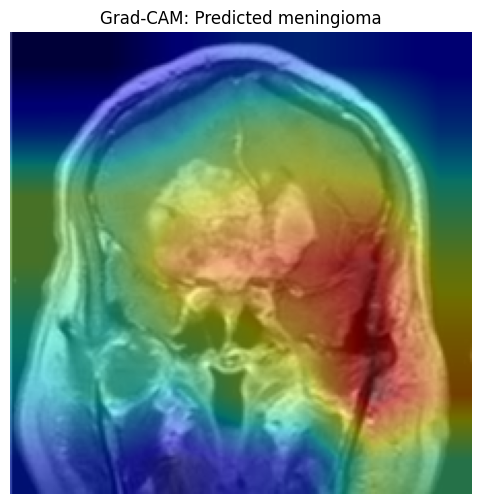

In [21]:
plt.figure(figsize=(6, 6))

plt.imshow(original_image.resize((224, 224)), cmap="gray")
plt.imshow(gradcam, cmap="jet", alpha=0.45)

plt.title(f"Grad-CAM: Predicted {predicted_class_name}")
plt.axis("off")

plt.show()

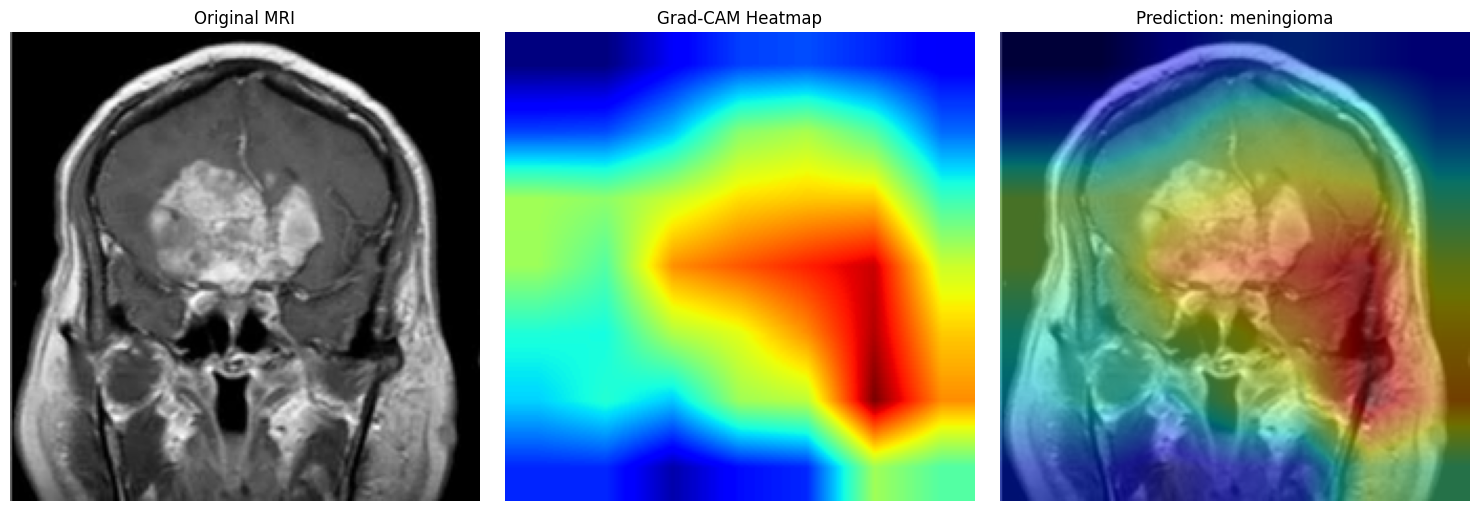

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(
    original_image.resize((224, 224)),
    cmap="gray"
)
axes[0].set_title("Original MRI")
axes[0].axis("off")

axes[1].imshow(gradcam, cmap="jet")
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(
    original_image.resize((224, 224)),
    cmap="gray"
)
axes[2].imshow(
    gradcam,
    cmap="jet",
    alpha=0.45
)

axes[2].set_title(
    f"Prediction: {predicted_class_name}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [23]:
def generate_gradcam(model, input_tensor, target_class):
    global activations, gradients

    activations = None
    gradients = None

    model.zero_grad()

    outputs = model(input_tensor)
    class_score = outputs[0, target_class]
    class_score.backward()

    weights = gradients.mean(dim=(2, 3), keepdim=True)

    gradcam = (weights * activations).sum(dim=1, keepdim=True)
    gradcam = F.relu(gradcam)

    gradcam = F.interpolate(
        gradcam,
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    )

    gradcam = gradcam.squeeze().cpu().numpy()
    gradcam = (gradcam - gradcam.min()) / (gradcam.max() - gradcam.min())

    return gradcam, outputs

In [24]:
def load_image_for_gradcam(image_path):
    original_image = Image.open(image_path).convert("L")
    input_tensor = transform(original_image).unsqueeze(0).to(device)

    return original_image, input_tensor

In [25]:
test_image_paths = []

for class_name in CLASSES:
    class_dir = TEST_DIR / class_name

    for image_path in class_dir.iterdir():
        if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            test_image_paths.append((image_path, CLASSES.index(class_name)))

In [26]:
correct_examples = []
incorrect_examples = []

model.eval()

for image_path, true_label in test_image_paths:
    original_image, input_tensor = load_image_for_gradcam(image_path)

    with torch.no_grad():
        outputs = model(input_tensor)
        predicted_label = outputs.argmax(dim=1).item()

    if predicted_label == true_label:
        correct_examples.append((image_path, true_label, predicted_label))
    else:
        incorrect_examples.append((image_path, true_label, predicted_label))

len(correct_examples), len(incorrect_examples)

(1456, 144)

In [33]:
def plot_gradcam_examples(examples, title, n=4, save_path=None):
    rng = random.Random(SEED)
    selected_examples = rng.sample(examples, n)

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

    for row, (image_path, true_label, predicted_label) in enumerate(selected_examples):
        original_image, input_tensor = load_image_for_gradcam(image_path)

        gradcam, outputs = generate_gradcam(
            model,
            input_tensor,
            target_class=predicted_label
        )

        resized_image = original_image.resize((224, 224))

        axes[row, 0].imshow(resized_image, cmap="gray")
        axes[row, 0].set_title(f"Original\nTrue: {CLASSES[true_label]}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gradcam, cmap="jet")
        axes[row, 1].set_title("Grad-CAM Heatmap")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(resized_image, cmap="gray")
        axes[row, 2].imshow(gradcam, cmap="jet", alpha=0.45)
        axes[row, 2].set_title(f"Overlay\nPred: {CLASSES[predicted_label]}")
        axes[row, 2].axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()

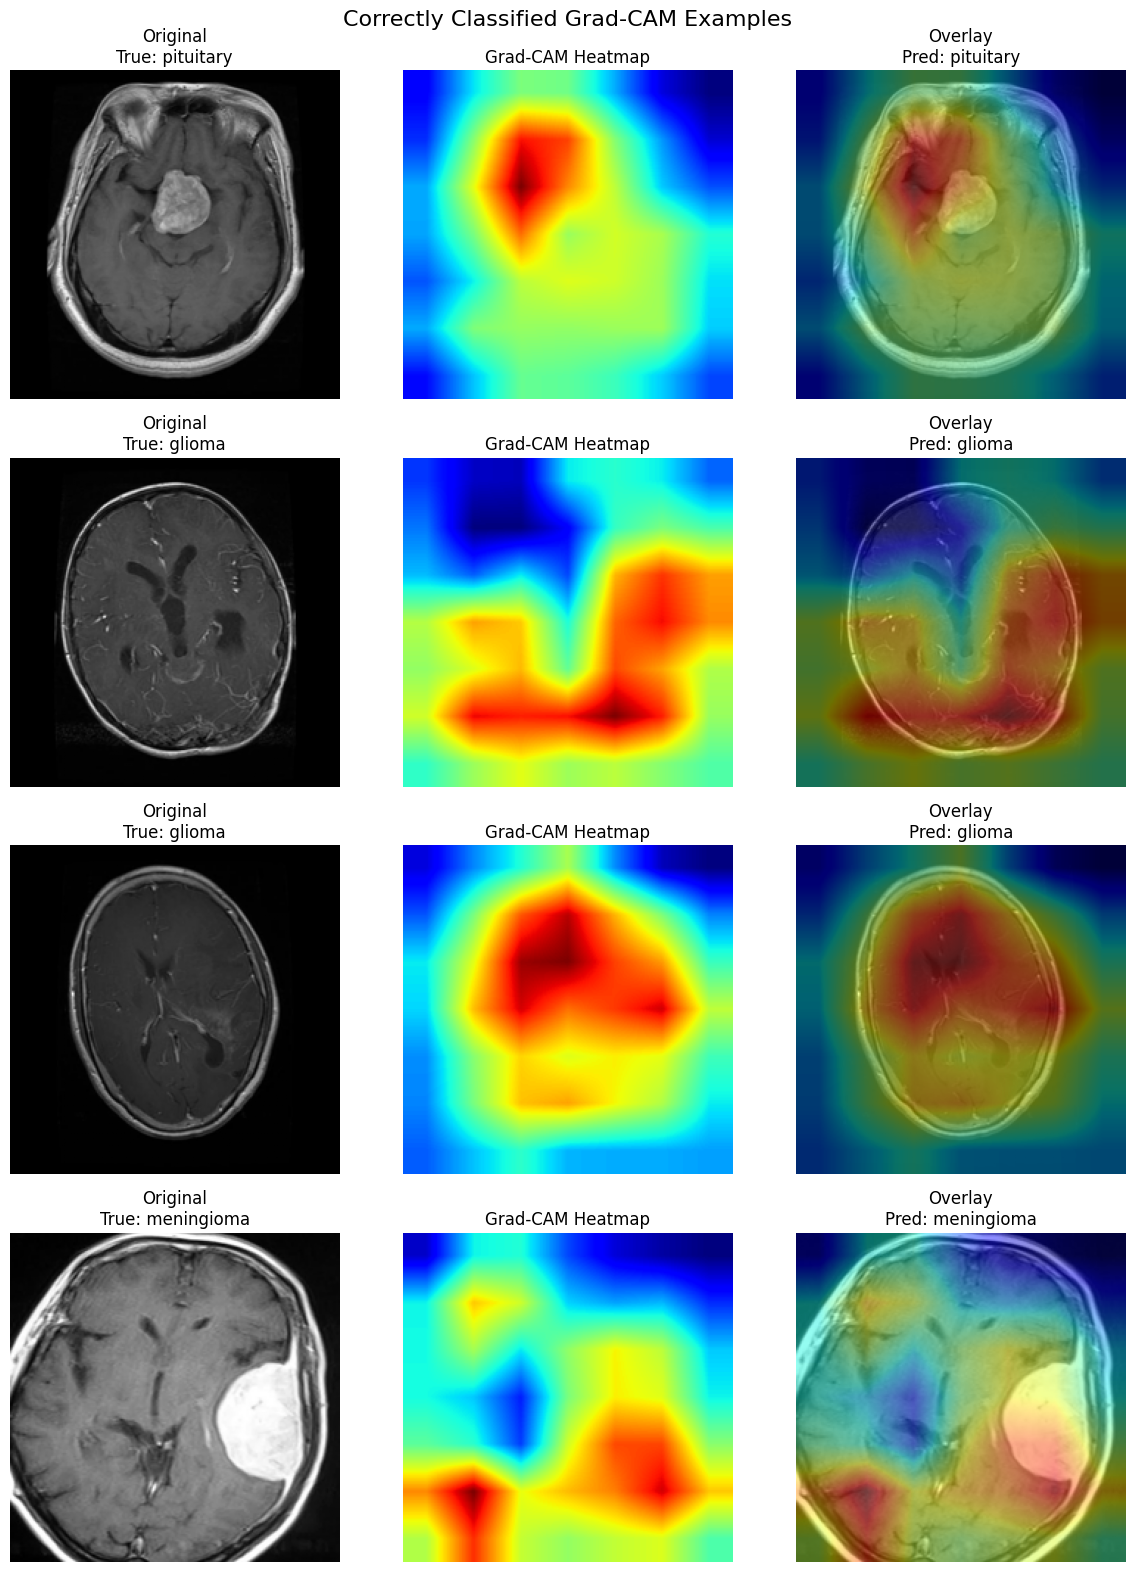

In [34]:
plot_gradcam_examples(
    correct_examples,
    title="Correctly Classified Grad-CAM Examples",
    n=4,
    save_path="../figures/gradcam_correct_examples.png"
)

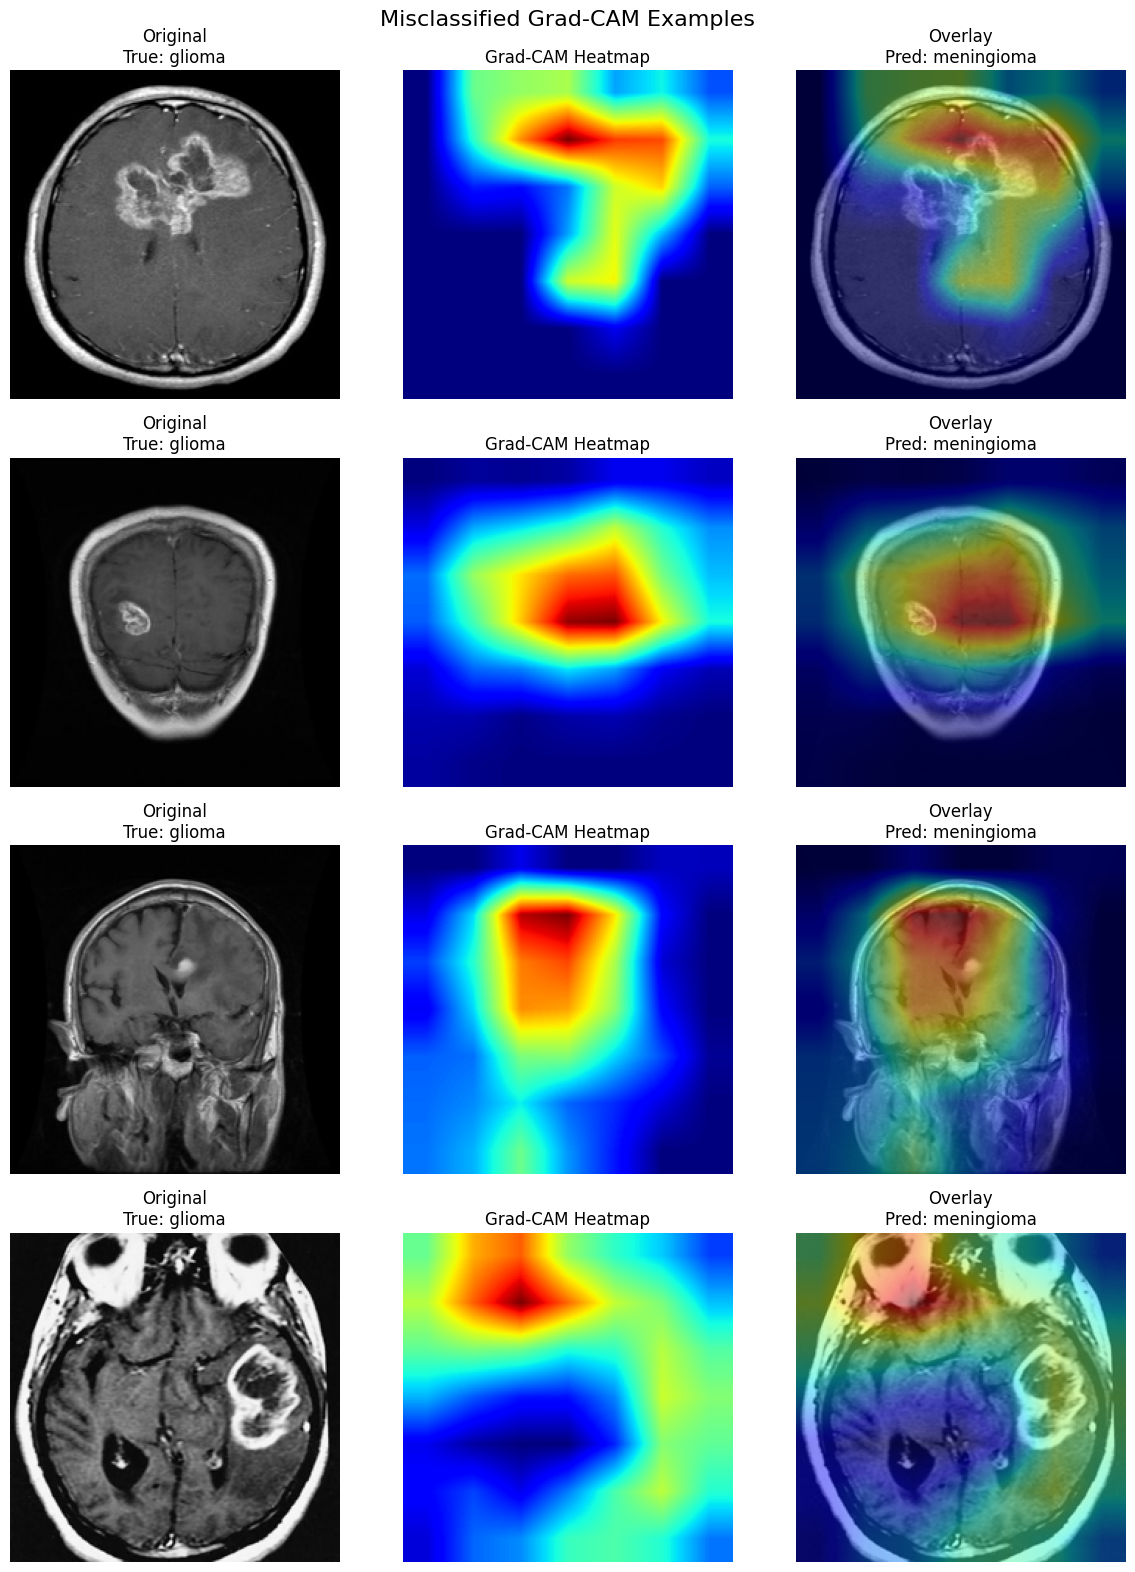

In [35]:
plot_gradcam_examples(
    incorrect_examples,
    title="Misclassified Grad-CAM Examples",
    n=4,
    save_path="../figures/gradcam_misclassified_examples.png"
)